# Facial Age Estimation — Demo Notebook



| # | Source       | Model                          | Task                              |
|---|--------------|--------------------------------|-----------------------------------|
| 1 | Parts 1 & 2  | best regression CNN            | regression (real-valued age)      |
| 2 | Parts 1 & 2  | best classification CNN        | classification (6 age categories) |
| 3 | Part 3       | ConvAutoencoder                | reconstruction (qualitative)      |
| 4 | Part 3       | Autoencoder-transfer classifier| classification (5 age categories) |
| 5 | Part 3       | ResNet-18 backbone classifier  | classification (5 age categories) |

Parts 1/2 use 6 age bins, Part 3 uses 5. Each model is evaluated against
the scheme it was trained on; the two are not directly comparable.




## 1. Configuration — URLs and local fallback


For each file, in order:

1. If the file already exists in the expected local path
   (e.g. `saved_models/best_regression.pth` or `data/test.csv`) → use it,
   no download.
2. Else if you provided a URL below → download it.
3. Else if the file is optional (any model) → skip it silently.
4. Else (only `test_data.zip` is required) → raise an error.


If a URL still contains `PASTE_` the notebook stops immediately with a
clear error instead of trying to download placeholder text.


In [ ]:

URLS = {
    # Part 1/2 models  - expected local path: saved_models/<name>
    'best_regression.pth'    : None,
    'best_classification.pth': None,

    # Part 3 models  -  expected local path: saved_models/<name>
    'autoencoder.pth'        : None,
    'transfer_classifier.pth': None,
    'backbone_resnet18.pth'  : None,

    # Test data zip  - expected local layout: data/test.csv + image folders
    'test_data.zip'          : None,
}

# Where local files live (these match the paths used by the training notebooks)
LOCAL_MODELS_DIR = 'saved_models'
LOCAL_TEST_CSV   = 'data/test.csv'

SEED = 42

## 2. Setup and imports

In [2]:
import os, sys, json, random, zipfile, shutil, urllib.request, urllib.error, ssl
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import (mean_absolute_error, accuracy_score,
                             confusion_matrix, classification_report)

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU   : {torch.cuda.get_device_name(0)}')

WORK_DIR = Path('demo_workspace')
WORK_DIR.mkdir(exist_ok=True)
print(f'Workspace: {WORK_DIR.resolve()}')

C:\Users\chand\AppData\Roaming\Python\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Device: cuda
GPU   : NVIDIA GeForce RTX 3050 Laptop GPU
Workspace: C:\profile_projects\12_may\demo_workspace


## 3. Download helper

Plain `urllib`, no third-party download libraries. Streams to disk with a
progress indicator, deletes partial files if a download fails, and skips
files that are already cached.

In [3]:
def _human(n_bytes):
    for unit in ('B', 'KB', 'MB', 'GB'):
        if n_bytes < 1024:
            return f'{n_bytes:6.1f} {unit}'
        n_bytes /= 1024
    return f'{n_bytes:6.1f} TB'


def _check_placeholder(url, name):
    if url is None:
        return False
    if 'PASTE_' in url or url.strip() == '':
        raise ValueError(
            f"URL for '{name}' is still a placeholder.\n"
            f"  current value: {url!r}\n"
            f"  -> edit the URLS dict in cell 2 and re-run."
        )
    if not url.startswith(('http://', 'https://')):
        raise ValueError(f"URL for '{name}' is not an http(s) URL: {url!r}")
    return True


def preflight(url, name):
    """HEAD request — surfaces 401/403/404 before the real download starts."""
    try:
        req = urllib.request.Request(url, method='HEAD',
                                     headers={'User-Agent': 'demo-notebook/1.0'})
        ctx = ssl.create_default_context()
        with urllib.request.urlopen(req, timeout=30, context=ctx) as resp:
            size = resp.headers.get('Content-Length')
            ct   = resp.headers.get('Content-Type', '?')
            size_str = _human(int(size)) if size else 'size unknown'
            print(f'  preflight {name:30s} OK   ({ct}, {size_str})')
    except urllib.error.HTTPError as e:
        print(f'  preflight {name:30s} HTTP {e.code} {e.reason}')
        if e.code in (401, 403):
            raise RuntimeError(
                f"{name}: server returned {e.code}. The URL works only with auth — "
                "make the file public, or use a different host."
            )
        if e.code == 404:
            raise RuntimeError(f"{name}: 404 Not Found. Check the URL is exact.")
        # 405 (Method Not Allowed) etc — some hosts reject HEAD; continue.
    except Exception as e:
        print(f'  preflight {name:30s} could not verify ({type(e).__name__}) — continuing')


def download(url, dest: Path, name=None):
    """Stream `url` to `dest`. Idempotent."""
    name = name or dest.name
    if dest.exists() and dest.stat().st_size > 0:
        print(f'  cached    {name:30s} {_human(dest.stat().st_size)}')
        return dest

    preflight(url, name)

    tmp = dest.with_suffix(dest.suffix + '.part')
    try:
        req = urllib.request.Request(url, headers={'User-Agent': 'demo-notebook/1.0'})
        with urllib.request.urlopen(req, timeout=60) as resp, open(tmp, 'wb') as f:
            total      = resp.headers.get('Content-Length')
            total_int  = int(total) if total else None
            downloaded = 0
            chunk      = 1024 * 256
            while True:
                buf = resp.read(chunk)
                if not buf:
                    break
                f.write(buf); downloaded += len(buf)
                if total_int:
                    pct = 100 * downloaded / total_int
                    print(f'\r    {name:30s} {_human(downloaded)} / {_human(total_int)} '
                          f'({pct:5.1f}%)', end='', flush=True)
                else:
                    print(f'\r    {name:30s} {_human(downloaded)}', end='', flush=True)
            print()
        tmp.replace(dest)
        print(f'  ok        {name:30s} {_human(dest.stat().st_size)}')
        return dest
    except Exception:
        if tmp.exists():
            tmp.unlink()
        raise

## 4. Resolve every file (local-first, URL fallback)

In [ ]:
for name, url in URLS.items():
    _check_placeholder(url, name)

downloads_dir = WORK_DIR / 'downloads'
downloads_dir.mkdir(exist_ok=True)

resolved = {}

print('Resolving artifacts (local-first):')
for name, url in URLS.items():
    # Local candidates depending on file type
    if name.endswith('.pth'):
        local_candidates = [Path(LOCAL_MODELS_DIR) / name,
                            Path('models') / name,
                            Path(name)]
    elif name == 'test_data.zip':
        if Path(LOCAL_TEST_CSV).exists():
            print(f'  local     {name:30s} -> using existing {LOCAL_TEST_CSV} (no zip needed)')
            resolved[name] = Path(LOCAL_TEST_CSV)
            continue
        local_candidates = [Path(name)]
    else:
        local_candidates = [Path(name)]

    # Local hit?
    local_hit = next((p for p in local_candidates if p.exists()), None)
    if local_hit is not None:
        print(f'  local     {name:30s} -> {local_hit}')
        resolved[name] = local_hit
        continue

    # URL provided?
    if url is not None:
        try:
            dest = downloads_dir / name
            download(url, dest, name=name)
            resolved[name] = dest
        except Exception as e:
            print(f'  FAILED    {name:30s} {type(e).__name__}: {e}')
        continue

    #  Nothing — skip optional, error on required
    if name == 'test_data.zip':
        raise RuntimeError(
            f"Cannot find test data. Either:\n"
            f"  (a) run the Part 1/2 training notebook so that '{LOCAL_TEST_CSV}' exists, or\n"
            f"  (b) place test_data.zip in the working directory, or\n"
            f"  (c) set URLS['test_data.zip'] to a download URL."
        )
    print(f'  skip      {name:30s} (no local file, no URL)')

print(f'\nResolved {len(resolved)} / {len(URLS)} artifacts.')

Resolving artifacts (local-first):
  local     best_regression.pth            -> saved_models\best_regression.pth
  local     best_classification.pth        -> saved_models\best_classification.pth
  local     autoencoder.pth                -> saved_models\autoencoder.pth
  local     transfer_classifier.pth        -> saved_models\transfer_classifier.pth
  local     backbone_resnet18.pth          -> saved_models\backbone_resnet18.pth
  local     test_data.zip                  -> using existing data/test.csv (no zip needed)

Resolved 6 / 6 artifacts.


## 5. Locate test.csv and resolve image paths

In [5]:
test_data_path = resolved['test_data.zip']

if test_data_path.is_file() and test_data_path.suffix.lower() == '.csv':
    # Local fallback: training notebook already produced data/test.csv
    TEST_CSV  = test_data_path
    data_root = test_data_path.parent.parent   # one level up from `data/`
    print(f'Using local test CSV: {TEST_CSV}')
elif test_data_path.is_file() and test_data_path.suffix.lower() == '.zip':
    # Zip — extract into the workspace if not already done
    data_root = WORK_DIR / 'test_data'
    if not data_root.exists():
        with zipfile.ZipFile(test_data_path) as zf:
            zf.extractall(data_root)
        print(f'extracted -> {data_root}')
    else:
        print(f'already extracted -> {data_root}')
    csvs = list(data_root.rglob('test.csv'))
    assert csvs, f'No test.csv found inside {data_root}'
    TEST_CSV = csvs[0]
    print(f'test.csv  : {TEST_CSV}')
else:
    raise RuntimeError(f'Unexpected test-data path: {test_data_path}')

test_df = pd.read_csv(TEST_CSV)

def find_root(df, csv_path, primary_root):
    candidates = [primary_root, csv_path.parent, csv_path.parent.parent,
                  data_root, WORK_DIR, Path('.')]
    if data_root.exists():
        candidates += [p for p in data_root.iterdir() if p.is_dir()]
    sample = df['path'].head(20).tolist()
    for root in candidates:
        ok = sum((Path(root) / s).exists() for s in sample)
        if ok > len(sample) // 2:
            return Path(root)
    if all(Path(s).exists() for s in sample):
        return None  # absolute paths already
    return None

root = find_root(test_df, TEST_CSV, data_root)
print(f'image root: {root if root is not None else "(absolute paths in CSV)"}')

def resolve(p):
    p = Path(p)
    if p.is_absolute() and p.exists():
        return p
    if root is None:
        return p
    return root / p

test_df['resolved'] = test_df['path'].apply(resolve)
missing = (~test_df['resolved'].apply(lambda x: Path(x).exists())).sum()
print(f'rows      : {len(test_df)}')
print(f'resolvable: {len(test_df) - missing} / {len(test_df)}')
if missing > 0:
    print('\nFirst few unresolved paths:')
    for p in test_df.loc[~test_df['resolved'].apply(lambda x: Path(x).exists()), 'path'].head():
        print(f'  - {p}')
    raise RuntimeError(
        'Some test images cannot be located. Either:\n'
        '  (a) ensure the directory structure referenced by the CSV exists alongside test.csv, or\n'
        '  (b) regenerate test.csv using paths that resolve from the current working dir.'
    )

TEST_RESOLVED_CSV = WORK_DIR / 'test_resolved.csv'
test_df.to_csv(TEST_RESOLVED_CSV, index=False)
print(f'wrote     : {TEST_RESOLVED_CSV}')

Using local test CSV: data\test.csv
image root: .
rows      : 977
resolvable: 977 / 977
wrote     : demo_workspace\test_resolved.csv


## 6. Categories, transforms, dataset

In [6]:
# Part 1/2 — 6 categories
CATEGORIES_P12 = [
    ('child',   0,  12), ('teen',   13,  19), ('youth',  20,  30),
    ('mid',    31,  45), ('mature', 46,  60), ('older',  61, 120),
]
CAT_NAMES_P12   = [c[0] for c in CATEGORIES_P12]
NUM_CLASSES_P12 = len(CATEGORIES_P12)

def age_to_cat_p12(age):
    for i, (_, lo, hi) in enumerate(CATEGORIES_P12):
        if lo <= age <= hi:
            return i
    return NUM_CLASSES_P12 - 1

# Part 3 — 5 categories
AGE_BINS_P3    = [0, 12, 18, 35, 65, 120]
CAT_NAMES_P3   = ['0-11', '12-17', '18-34', '35-64', '65+']
NUM_CLASSES_P3 = 5

def age_to_cat_p3(age):
    return int(pd.cut([age], bins=AGE_BINS_P3,
                      labels=list(range(NUM_CLASSES_P3)), right=False)[0])

IMG_SIZE = 64
AE_SIZE  = 128
BB_SIZE  = 224

def tf_flex(channels=3):
    return transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*channels, [0.5]*channels),
    ])

tf_ae = transforms.Compose([
    transforms.Resize((AE_SIZE, AE_SIZE)), transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

tf_bb = transforms.Compose([
    transforms.Resize((BB_SIZE, BB_SIZE)), transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

class TestDataset(Dataset):
    def __init__(self, csv_path, transform, channels=3):
        self.df        = pd.read_csv(csv_path)
        self.transform = transform
        self.channels  = channels
        self.df['_cat_p12'] = self.df['age'].apply(age_to_cat_p12)
        self.df['_cat_p3']  = self.df['age'].apply(age_to_cat_p3)
        self.path_col = 'resolved' if 'resolved' in self.df.columns else 'path'

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        mode = 'L' if self.channels == 1 else 'RGB'
        img  = Image.open(row[self.path_col]).convert(mode)
        if self.transform:
            img = self.transform(img)
        return (img,
                torch.tensor(row['age'],      dtype=torch.float32),
                torch.tensor(row['_cat_p12'], dtype=torch.long),
                torch.tensor(row['_cat_p3'],  dtype=torch.long))

print('Categories, transforms, and dataset class ready.')

Categories, transforms, and dataset class ready.


## 7. Model architectures — Parts 1 & 2

In [7]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=3, activation=nn.ReLU, use_pool=True):
        super().__init__()
        pad    = kernel // 2
        layers = [nn.Conv2d(in_ch, out_ch, kernel, padding=pad),
                  nn.BatchNorm2d(out_ch), activation()]
        if use_pool:
            layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)
    def forward(self, x):
        return self.block(x)


class FlexCNN(nn.Module):
    def __init__(self, depth=3, kernel=3, activation=nn.ReLU,
                 use_pool=True, fc_layers=None, task='regression', channels=3,
                 num_classes=NUM_CLASSES_P12):
        super().__init__()
        if fc_layers is None:
            fc_layers = [256, 128]
        self.task = task
        ch_seq    = [channels] + [min(32 * 2**i, 256) for i in range(depth)]
        self.features = nn.Sequential(*[
            ConvBlock(ch_seq[i], ch_seq[i+1], kernel, activation, use_pool)
            for i in range(depth)
        ])
        with torch.no_grad():
            feat_size = self.features(
                torch.zeros(1, channels, IMG_SIZE, IMG_SIZE)).numel()
        fc_in, parts = feat_size, []
        for fc_out in fc_layers:
            parts += [nn.Linear(fc_in, fc_out), activation(), nn.Dropout(0.4)]
            fc_in  = fc_out
        parts.append(nn.Linear(fc_in, 1 if task == 'regression' else num_classes))
        self.classifier = nn.Sequential(*parts)
    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))


class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, activation=nn.ReLU):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch,  out_ch, 3, padding=1)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.act   = activation()
        self.proj  = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.pool  = nn.MaxPool2d(2)
    def forward(self, x):
        res = self.proj(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.pool(self.act(out + res))


class ResCNN(nn.Module):
    def __init__(self, depth=3, activation=nn.ReLU,
                 fc_layers=None, task='regression', channels=3,
                 num_classes=NUM_CLASSES_P12):
        super().__init__()
        if fc_layers is None:
            fc_layers = [256, 128]
        self.task = task
        ch_seq    = [channels] + [min(32 * 2**i, 256) for i in range(depth)]
        self.features = nn.Sequential(*[
            ResBlock(ch_seq[i], ch_seq[i+1], activation) for i in range(depth)
        ])
        with torch.no_grad():
            feat_size = self.features(
                torch.zeros(1, channels, IMG_SIZE, IMG_SIZE)).numel()
        fc_in, parts = feat_size, []
        for fc_out in fc_layers:
            parts += [nn.Linear(fc_in, fc_out), activation(), nn.Dropout(0.4)]
            fc_in  = fc_out
        parts.append(nn.Linear(fc_in, 1 if task == 'regression' else num_classes))
        self.classifier = nn.Sequential(*parts)
    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))


class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch, activation=nn.ReLU):
        super().__init__()
        bch        = max(out_ch // 3, 8)
        self.b3    = nn.Sequential(nn.Conv2d(in_ch, bch, 3, padding=1), nn.BatchNorm2d(bch), activation())
        self.b5    = nn.Sequential(nn.Conv2d(in_ch, bch, 5, padding=2), nn.BatchNorm2d(bch), activation())
        self.b7    = nn.Sequential(nn.Conv2d(in_ch, bch, 7, padding=3), nn.BatchNorm2d(bch), activation())
        self.merge = nn.Conv2d(bch * 3, out_ch, 1)
        self.pool  = nn.MaxPool2d(2)
    def forward(self, x):
        x = torch.cat([self.b3(x), self.b5(x), self.b7(x)], dim=1)
        return self.pool(self.merge(x))


class MultiScaleCNN(nn.Module):
    def __init__(self, depth=3, activation=nn.ReLU,
                 fc_layers=None, task='regression', channels=3,
                 num_classes=NUM_CLASSES_P12):
        super().__init__()
        if fc_layers is None:
            fc_layers = [256, 128]
        self.task = task
        ch_seq    = [channels] + [min(32 * 2**i, 128) for i in range(depth)]
        self.features = nn.Sequential(*[
            MultiScaleBlock(ch_seq[i], ch_seq[i+1], activation) for i in range(depth)
        ])
        with torch.no_grad():
            feat_size = self.features(
                torch.zeros(1, channels, IMG_SIZE, IMG_SIZE)).numel()
        fc_in, parts = feat_size, []
        for fc_out in fc_layers:
            parts += [nn.Linear(fc_in, fc_out), activation(), nn.Dropout(0.4)]
            fc_in  = fc_out
        parts.append(nn.Linear(fc_in, 1 if task == 'regression' else num_classes))
        self.classifier = nn.Sequential(*parts)
    def forward(self, x):
        return self.classifier(self.features(x).flatten(1))


class FlexCNN_Softmax(FlexCNN):
    def forward(self, x):
        return F.softmax(super().forward(x), dim=-1)


MODEL_REGISTRY_P12 = {
    'FlexCNN':         FlexCNN,
    'ResCNN':          ResCNN,
    'MultiScaleCNN':   MultiScaleCNN,
    'FlexCNN_Softmax': FlexCNN_Softmax,
}
print('Part 1/2 model classes defined.')

Part 1/2 model classes defined.


## 8. Model architectures — Part 3

In [8]:
class ConvAutoencoder(nn.Module):
    def __init__(self, latent_dim: int = 512):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = nn.Sequential(
            nn.Conv2d(3,   32,  3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32,  64,  3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64,  128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.flatten   = nn.Flatten()
        self.fc_enc    = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_dec    = nn.Linear(latent_dim, 256 * 4 * 4)
        self.unflatten = nn.Unflatten(1, (256, 4, 4))
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 256, 2, stride=2), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(256, 128, 2, stride=2), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.ConvTranspose2d(128, 64,  2, stride=2), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64,  32,  2, stride=2), nn.BatchNorm2d(32),  nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32,  3,   2, stride=2),
            nn.Tanh(),
        )
    def encode(self, x): return self.fc_enc(self.flatten(self.encoder(x)))
    def decode(self, z): return self.decoder(self.unflatten(self.fc_dec(z)))
    def forward(self, x):
        z     = self.encode(x)
        recon = self.decode(z)
        return recon, z


class AEClassifier(nn.Module):
    def __init__(self, ae_model: ConvAutoencoder,
                 num_classes=NUM_CLASSES_P3, latent_dim=512):
        super().__init__()
        self.encoder = ae_model.encoder
        self.flatten = ae_model.flatten
        self.fc_enc  = ae_model.fc_enc
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 256), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(256, 128),        nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        z = self.fc_enc(self.flatten(self.encoder(x)))
        return self.classifier(z)


class BackboneClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES_P3):
        super().__init__()
        base          = models.resnet18(weights=None)
        in_feats      = base.fc.in_features
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_feats, 256), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(256, 128),      nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.head(self.backbone(x))

print('Part 3 model classes defined.')

Part 3 model classes defined.


## 9. Load whichever models are available

Each model is loaded independently. If a file is missing, that model is
skipped — only the models you actually provided URLs for get evaluated.

In [9]:
loaded = {}     # name -> (model, info_dict)

def load_p12(path: Path):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)
    sk   = ckpt['model_state_dict'].keys()
    bidx = [int(k.split('.')[1]) for k in sk if k.startswith('features.')]
    depth = max(bidx) + 1 if bidx else 3
    cls   = MODEL_REGISTRY_P12[ckpt['model_class']]
    model = cls(depth=depth, task=ckpt['task'], channels=ckpt['channels'])
    model.load_state_dict(ckpt['model_state_dict'])
    model = model.to(DEVICE).eval()
    info = dict(model_class=ckpt['model_class'], task=ckpt['task'],
                channels=ckpt['channels'], depth=depth)
    return model, info


def load_p3(model: nn.Module, path: Path):
    sd = torch.load(path, map_location=DEVICE, weights_only=True)
    if isinstance(sd, dict) and 'state_dict' in sd and not any(
            k.startswith(('encoder', 'backbone', 'head', 'classifier', 'fc_')) for k in sd):
        sd = sd['state_dict']
    res = model.load_state_dict(sd, strict=False)
    if res.missing_keys or res.unexpected_keys:
        print(f'    note: missing={len(res.missing_keys)} unexpected={len(res.unexpected_keys)}')
    return model.to(DEVICE).eval()


def try_load(fname, loader):
    path = resolved.get(fname)
    if path is None or not Path(path).exists():
        print(f'  skip      {fname:30s} (not resolved)')
        return None
    try:
        result = loader(Path(path))
        print(f'  loaded    {fname:30s} from {path}')
        return result
    except Exception as e:
        print(f'  FAILED    {fname}: {type(e).__name__}: {e}')
        return None


for key in ('best_regression.pth', 'best_classification.pth'):
    r = try_load(key, load_p12)
    if r is not None:
        model, info = r
        loaded[key.replace('.pth', '')] = (model, info)

r = try_load('autoencoder.pth', lambda p: load_p3(ConvAutoencoder(latent_dim=512), p))
if r is not None: loaded['autoencoder'] = (r, dict(task='reconstruction'))

r = try_load('transfer_classifier.pth',
             lambda p: load_p3(AEClassifier(ConvAutoencoder(latent_dim=512),
                                            num_classes=NUM_CLASSES_P3), p))
if r is not None: loaded['transfer_classifier'] = (r, dict(task='classification_p3'))

r = try_load('backbone_resnet18.pth',
             lambda p: load_p3(BackboneClassifier(num_classes=NUM_CLASSES_P3), p))
if r is not None: loaded['backbone_resnet18'] = (r, dict(task='classification_p3'))

print(f'\n{len(loaded)} model(s) loaded: {list(loaded.keys())}')

  loaded    best_regression.pth            from saved_models\best_regression.pth
  loaded    best_classification.pth        from saved_models\best_classification.pth
    note: missing=60 unexpected=4
  loaded    autoencoder.pth                from saved_models\autoencoder.pth
    note: missing=38 unexpected=2
  loaded    transfer_classifier.pth        from saved_models\transfer_classifier.pth
    note: missing=106 unexpected=2
  loaded    backbone_resnet18.pth          from saved_models\backbone_resnet18.pth

5 model(s) loaded: ['best_regression', 'best_classification', 'autoencoder', 'transfer_classifier', 'backbone_resnet18']


## 10. Evaluate

In [10]:
@torch.no_grad()
def eval_regression(model, csv_path, channels):
    ds = TestDataset(csv_path, transform=tf_flex(channels), channels=channels)
    dl = DataLoader(ds, batch_size=64, shuffle=False)
    preds, trues = [], []
    for imgs, ages, _, _ in dl:
        out = model(imgs.to(DEVICE)).squeeze(1)
        preds.extend(out.cpu().numpy()); trues.extend(ages.numpy())
    preds = np.array(preds); trues = np.array(trues)
    return dict(mae=mean_absolute_error(trues, preds),
                rmse=float(np.sqrt(np.mean((preds - trues) ** 2))),
                trues=trues, preds=preds)


@torch.no_grad()
def eval_classifier(model, csv_path, transform, channels, label_key):
    ds = TestDataset(csv_path, transform=transform, channels=channels)
    dl = DataLoader(ds, batch_size=64, shuffle=False)
    preds, trues = [], []
    for imgs, _, cat12, cat3 in dl:
        labels = cat12 if label_key == 'p12' else cat3
        out = model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
        preds.extend(out); trues.extend(labels.numpy())
    preds = np.array(preds); trues = np.array(trues)
    return dict(acc=accuracy_score(trues, preds), trues=trues, preds=preds)


results = {}

if 'best_regression' in loaded:
    m, info = loaded['best_regression']
    print('Eval: best regression (Part 1/2)')
    results['best_regression'] = eval_regression(m, TEST_RESOLVED_CSV, info['channels'])
    r = results['best_regression']
    print(f'  MAE = {r["mae"]:.3f} y    RMSE = {r["rmse"]:.3f} y')

if 'best_classification' in loaded:
    m, info = loaded['best_classification']
    print('\nEval: best classification (Part 1/2, 6-cat)')
    results['best_classification'] = eval_classifier(m, TEST_RESOLVED_CSV,
                                                     tf_flex(info['channels']),
                                                     info['channels'], 'p12')
    print(f'  Acc = {results["best_classification"]["acc"]:.4f}')

if 'transfer_classifier' in loaded:
    print('\nEval: AE-transfer classifier (Part 3, 5-cat)')
    results['transfer_classifier'] = eval_classifier(
        loaded['transfer_classifier'][0], TEST_RESOLVED_CSV, tf_ae, 3, 'p3')
    print(f'  Acc = {results["transfer_classifier"]["acc"]:.4f}')

if 'backbone_resnet18' in loaded:
    print('\nEval: ResNet-18 backbone (Part 3, 5-cat)')
    results['backbone_resnet18'] = eval_classifier(
        loaded['backbone_resnet18'][0], TEST_RESOLVED_CSV, tf_bb, 3, 'p3')
    print(f'  Acc = {results["backbone_resnet18"]["acc"]:.4f}')

Eval: best regression (Part 1/2)
  MAE = 5.485 y    RMSE = 8.171 y

Eval: best classification (Part 1/2, 6-cat)
  Acc = 0.7103

Eval: AE-transfer classifier (Part 3, 5-cat)
  Acc = 0.2559

Eval: ResNet-18 backbone (Part 3, 5-cat)
  Acc = 0.1064


## 11. Regression diagnostics

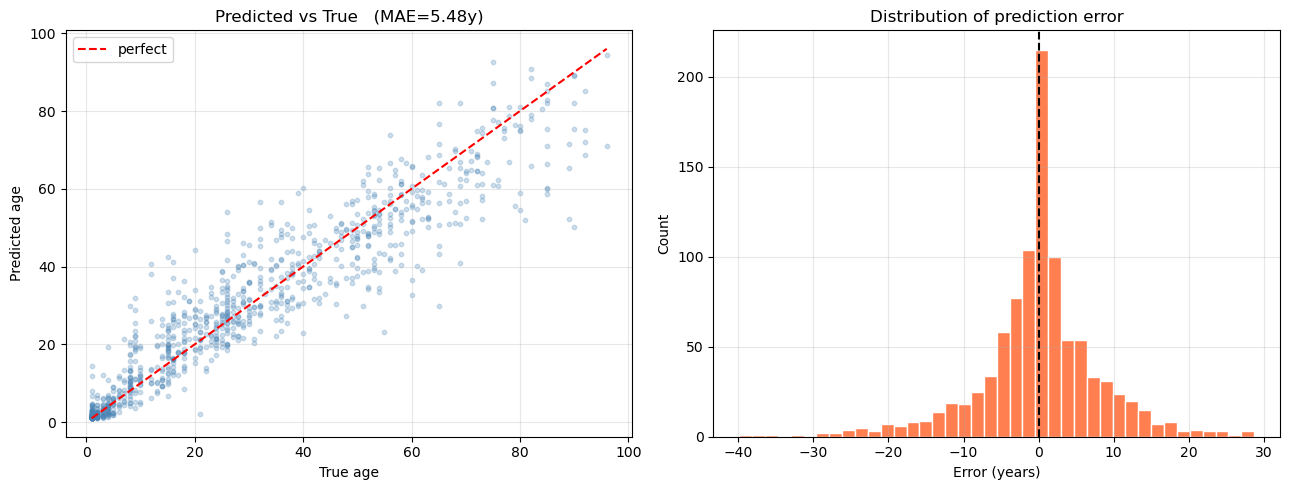

In [11]:
if 'best_regression' in results:
    r = results['best_regression']
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
    ax1.scatter(r['trues'], r['preds'], alpha=0.25, s=10, color='steelblue')
    lo, hi = r['trues'].min(), r['trues'].max()
    ax1.plot([lo, hi], [lo, hi], 'r--', label='perfect')
    ax1.set_xlabel('True age'); ax1.set_ylabel('Predicted age')
    ax1.set_title(f'Predicted vs True   (MAE={r["mae"]:.2f}y)')
    ax1.legend(); ax1.grid(alpha=0.3)

    err = r['preds'] - r['trues']
    ax2.hist(err, bins=40, color='coral', edgecolor='white')
    ax2.axvline(0, color='black', linestyle='--')
    ax2.set_xlabel('Error (years)'); ax2.set_ylabel('Count')
    ax2.set_title('Distribution of prediction error')
    ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()
else:
    print('No regression model loaded — skipping.')

## 12. Classification diagnostics

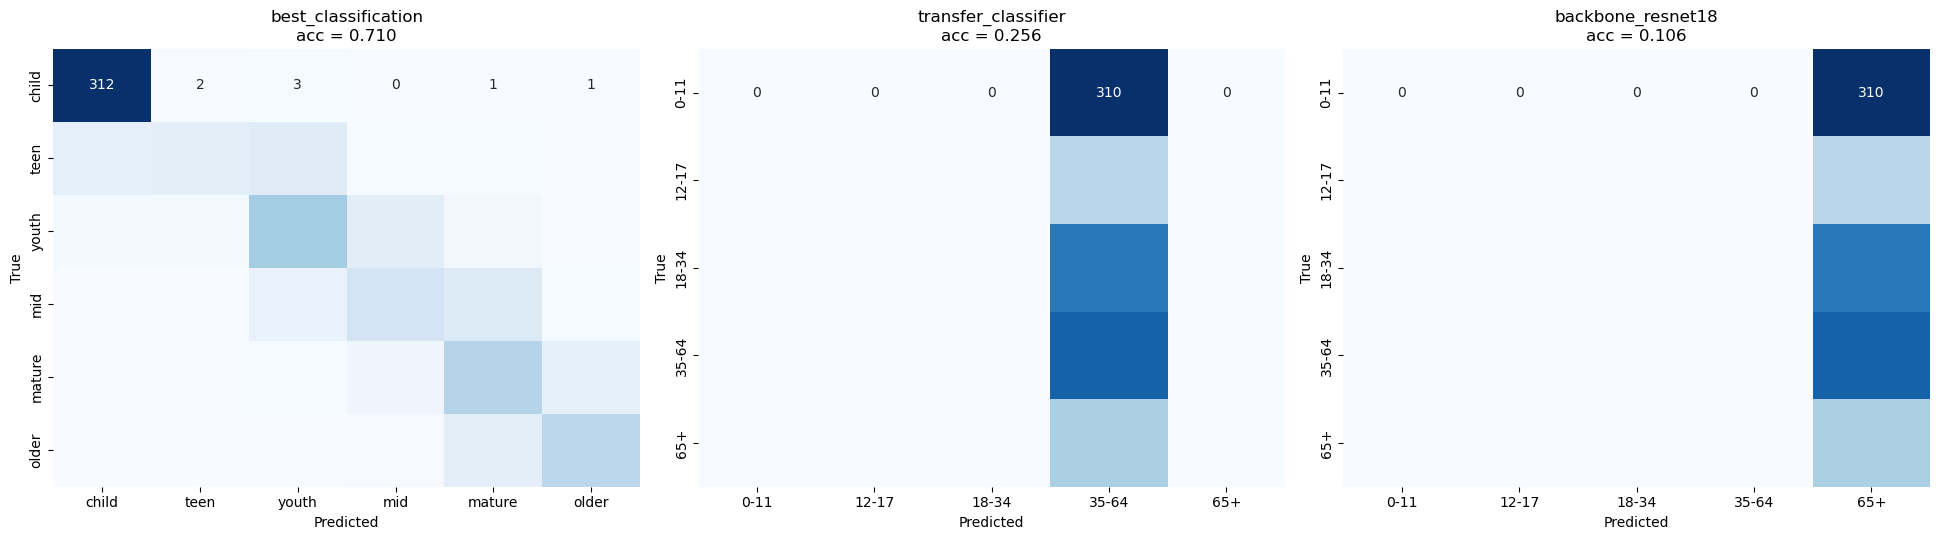


----- best_classification -----
              precision    recall  f1-score   support

       child       0.90      0.98      0.94       319
        teen       0.82      0.30      0.44       106
       youth       0.63      0.67      0.65       166
         mid       0.51      0.45      0.48       124
      mature       0.52      0.67      0.59       140
       older       0.73      0.72      0.72       122

    accuracy                           0.71       977
   macro avg       0.68      0.63      0.64       977
weighted avg       0.72      0.71      0.70       977


----- transfer_classifier -----
              precision    recall  f1-score   support

        0-11       0.00      0.00      0.00       310
       12-17       0.00      0.00      0.00        90
       18-34       0.00      0.00      0.00       223
       35-64       0.26      1.00      0.41       250
         65+       0.00      0.00      0.00       104

    accuracy                           0.26       977
   macro av

In [12]:
def plot_cm(ax, trues, preds, names, title):
    cm = confusion_matrix(trues, preds, labels=list(range(len(names))))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=names, yticklabels=names, ax=ax, cbar=False)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)


cls_specs = [
    ('best_classification',  CAT_NAMES_P12),
    ('transfer_classifier',  CAT_NAMES_P3),
    ('backbone_resnet18',    CAT_NAMES_P3),
]
cls_results = [(k, results[k], names) for k, names in cls_specs if k in results]

if cls_results:
    fig, axes = plt.subplots(1, len(cls_results), figsize=(6.5 * len(cls_results), 5.5))
    if len(cls_results) == 1: axes = [axes]
    for ax, (key, res, names) in zip(axes, cls_results):
        plot_cm(ax, res['trues'], res['preds'], names, f'{key}\nacc = {res["acc"]:.3f}')
    plt.tight_layout(); plt.show()

    for key, res, names in cls_results:
        print(f'\n----- {key} -----')
        print(classification_report(res['trues'], res['preds'],
                                    labels=list(range(len(names))),
                                    target_names=names, zero_division=0))
else:
    print('No classification models loaded — skipping.')

## 13. Autoencoder reconstructions

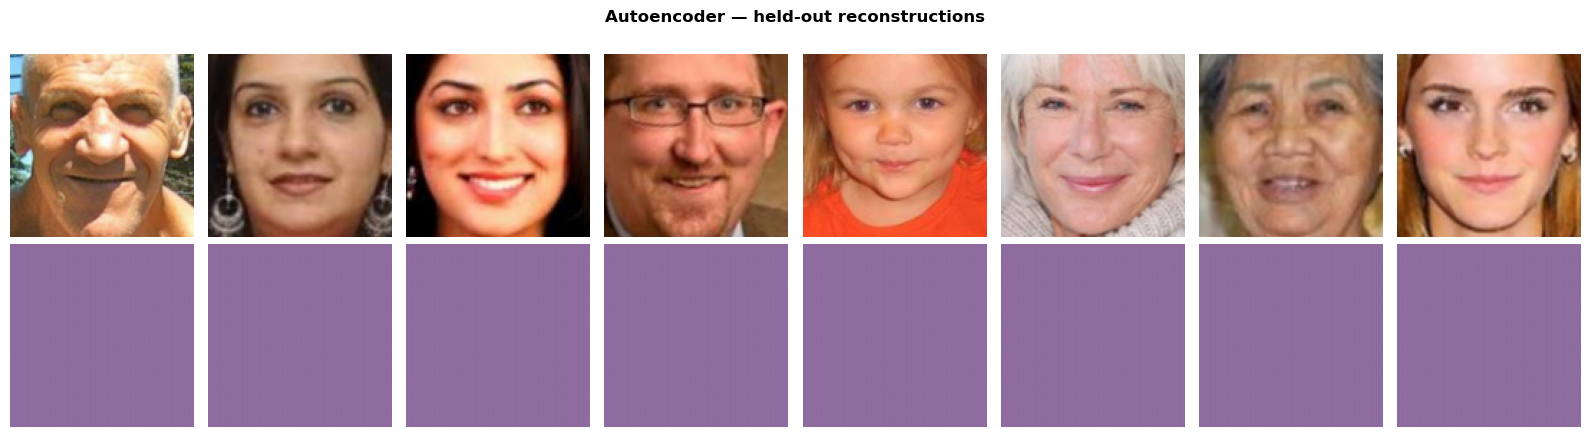

In [13]:
if 'autoencoder' in loaded:
    ae_model = loaded['autoencoder'][0]
    ds       = TestDataset(TEST_RESOLVED_CSV, transform=tf_ae, channels=3)

    idxs = random.sample(range(len(ds)), 8)
    imgs = torch.stack([ds[i][0] for i in idxs]).to(DEVICE)
    with torch.no_grad():
        recon, _ = ae_model(imgs)

    def denorm(t): return (t * 0.5 + 0.5).clamp(0, 1)

    fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
    for col in range(8):
        axes[0, col].imshow(denorm(imgs[col]).cpu().permute(1, 2, 0).numpy())
        axes[1, col].imshow(denorm(recon[col]).cpu().permute(1, 2, 0).numpy())
        for r in (0, 1): axes[r, col].axis('off')
    axes[0, 0].set_ylabel('original',       rotation=0, ha='right', va='center')
    axes[1, 0].set_ylabel('reconstruction', rotation=0, ha='right', va='center')
    plt.suptitle('Autoencoder — held-out reconstructions', fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('Autoencoder not loaded — skipping.')

## 14. Side-by-side sample predictions

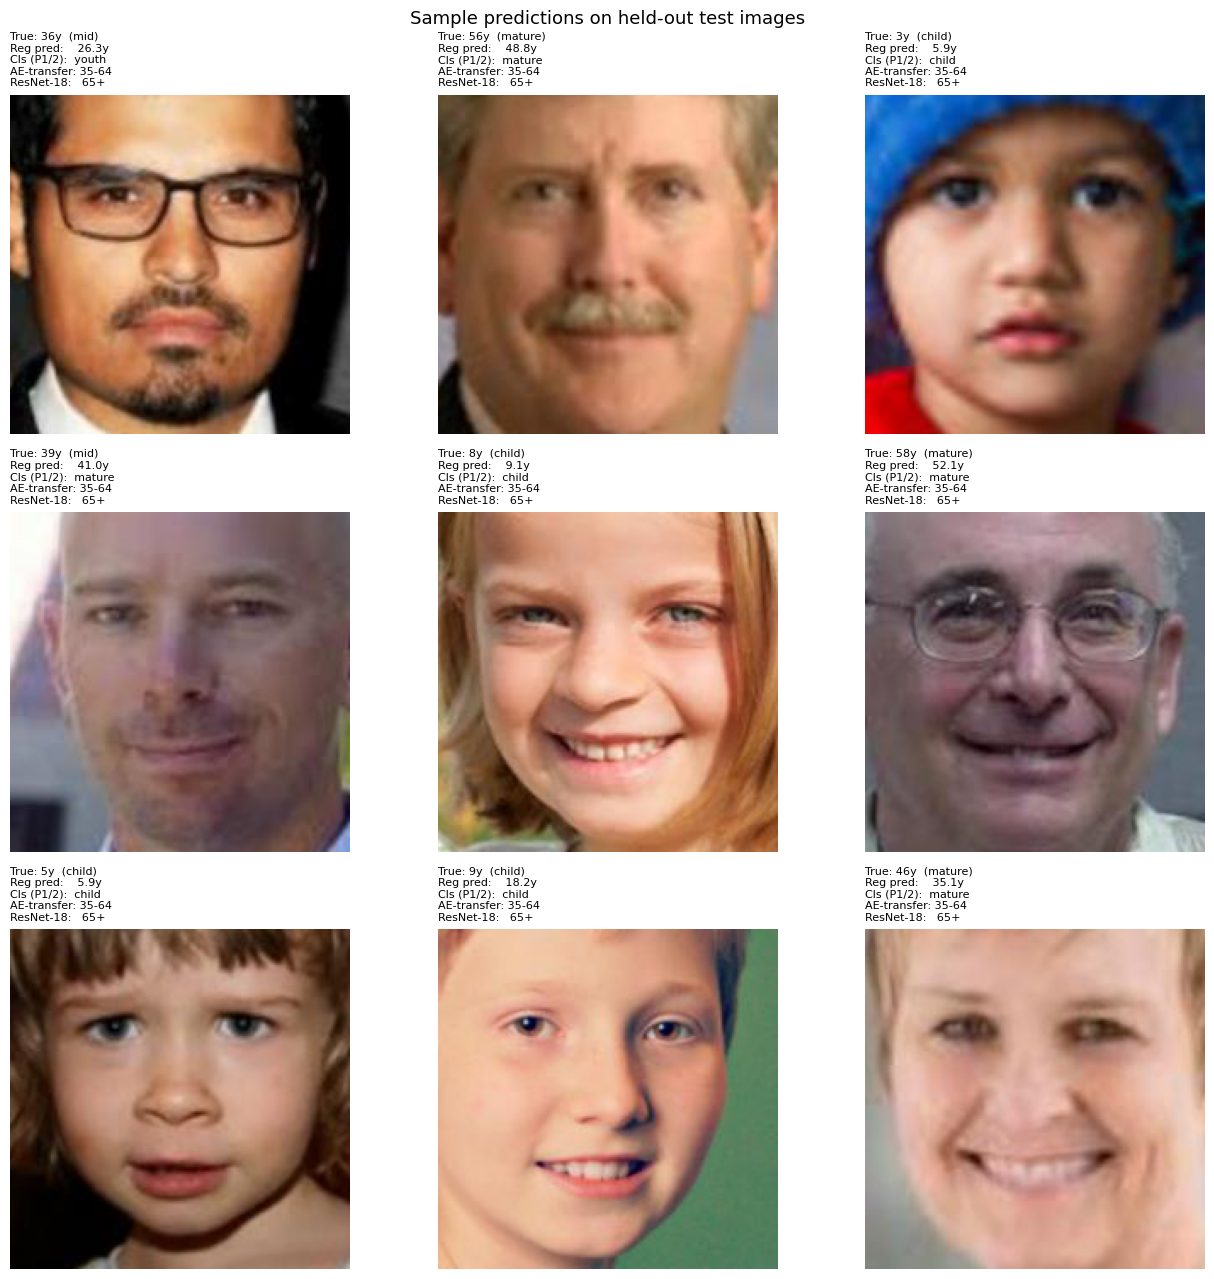

In [14]:
def predict_one(image_pil, model_key):
    model, info = loaded[model_key]
    if model_key in ('best_regression', 'best_classification'):
        ch = info['channels']
        x = tf_flex(ch)(image_pil.convert('L' if ch == 1 else 'RGB'))
    elif model_key == 'transfer_classifier':
        x = tf_ae(image_pil.convert('RGB'))
    elif model_key == 'backbone_resnet18':
        x = tf_bb(image_pil.convert('RGB'))
    else:
        return None
    x = x.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = model(x)
    return f'{out.item():.1f}y' if model_key == 'best_regression' else out.argmax(1).item()


sample = test_df.sample(min(9, len(test_df)), random_state=SEED).reset_index(drop=True)

fig, axes = plt.subplots(3, 3, figsize=(13, 13))
for ax, (_, row) in zip(axes.flat, sample.iterrows()):
    img = Image.open(row['resolved']).convert('RGB')
    ax.imshow(img); ax.axis('off')

    lines = [f'True: {int(row["age"])}y  ({CAT_NAMES_P12[age_to_cat_p12(row["age"])]})']
    if 'best_regression'     in loaded: lines.append(f'Reg pred:    {predict_one(img, "best_regression")}')
    if 'best_classification' in loaded: lines.append(f'Cls (P1/2):  {CAT_NAMES_P12[predict_one(img, "best_classification")]}')
    if 'transfer_classifier' in loaded: lines.append(f'AE-transfer: {CAT_NAMES_P3[predict_one(img, "transfer_classifier")]}')
    if 'backbone_resnet18'   in loaded: lines.append(f'ResNet-18:   {CAT_NAMES_P3[predict_one(img, "backbone_resnet18")]}')

    ax.set_title('\n'.join(lines), fontsize=8, loc='left')

plt.suptitle('Sample predictions on held-out test images', fontsize=13)
plt.tight_layout(); plt.show()

## 15. Final summary table

In [15]:
rows = []
if 'best_regression' in results:
    r = results['best_regression']
    rows.append(('Part 1/2', 'best regression CNN', 'regression',
                 f'MAE = {r["mae"]:.3f} yr / RMSE = {r["rmse"]:.3f} yr'))
if 'best_classification' in results:
    rows.append(('Part 1/2', 'best classification CNN', 'classification (6 cat)',
                 f'Acc = {results["best_classification"]["acc"]:.4f}'))
if 'transfer_classifier' in results:
    rows.append(('Part 3',   'AE-transfer classifier',   'classification (5 cat)',
                 f'Acc = {results["transfer_classifier"]["acc"]:.4f}'))
if 'backbone_resnet18' in results:
    rows.append(('Part 3',   'ResNet-18 backbone',       'classification (5 cat)',
                 f'Acc = {results["backbone_resnet18"]["acc"]:.4f}'))

summary = pd.DataFrame(rows, columns=['Part', 'Model', 'Task', 'Test result'])
print(summary.to_string(index=False))
summary.to_csv(WORK_DIR / 'demo_summary.csv', index=False)
print(f'\nSaved: {WORK_DIR / "demo_summary.csv"}')

    Part                   Model                   Task                      Test result
Part 1/2     best regression CNN             regression MAE = 5.485 yr / RMSE = 8.171 yr
Part 1/2 best classification CNN classification (6 cat)                     Acc = 0.7103
  Part 3  AE-transfer classifier classification (5 cat)                     Acc = 0.2559
  Part 3      ResNet-18 backbone classification (5 cat)                     Acc = 0.1064

Saved: demo_workspace\demo_summary.csv
